In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import r2_score

import sys
sys.path.append('../')
from mlcore.linear_regression import CustomLinearRegression

In [2]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

X, y = datasets.make_regression(
    n_samples=1_00_000, n_features=4, noise=20, random_state=4
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

model = CustomLinearRegression(learning_rate=0.01, n_iters=1000)
history = model.fit(X_train, y_train)
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

accu = r2_score(y_test, predictions)
print("Accuracy:", accu)

Early stopping at iteration 824 (no improvement for 10 rounds)
MSE: 396.11959495106385
Accuracy: 0.9734964538290766


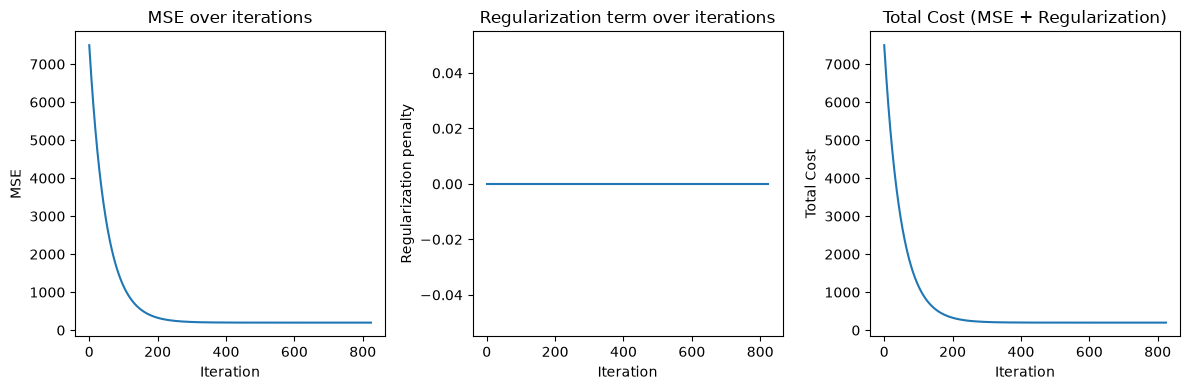

In [3]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history['mse_history'])
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE over iterations')

plt.subplot(1, 3, 2)
plt.plot(history['regularization_history'])
plt.xlabel('Iteration')
plt.ylabel('Regularization penalty')
plt.title('Regularization term over iterations')

plt.subplot(1, 3, 3)
plt.plot(history['cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Total Cost')
plt.title('Total Cost (MSE + Regularization)')

plt.tight_layout()
plt.show()

In [4]:
model_og = LinearRegression()
model_og.fit(X_train, y_train)
predictions_og = model_og.predict(X_test)


mse_og = mean_squared_error(y_test, predictions_og)
print("MSE:", mse_og)

accu_og = r2_score(y_test, predictions_og)
print("Accuracy:", accu_og)

MSE: 396.1081766994279
Accuracy: 0.9734972178007741


### with regularization

In [16]:
model = CustomLinearRegression(learning_rate=0.001, n_iters=5000, l1=True, alpha=0.1, tol=1e-4, patience=50)
history_l1 = model.fit(X_train, y_train)
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

accu = r2_score(y_test, predictions)
print("Accuracy:", accu)

MSE: 397.0146991141642
Accuracy: 0.9734365642532593


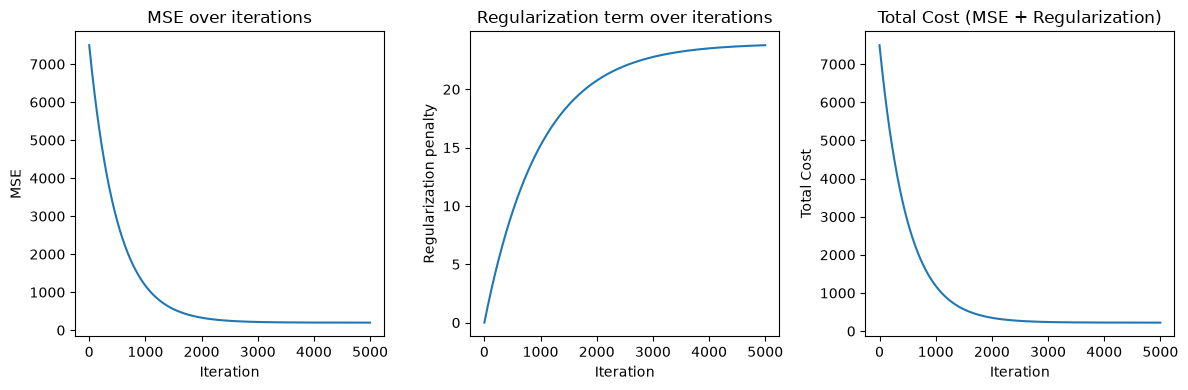

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history_l1['mse_history'])
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE over iterations')

plt.subplot(1, 3, 2)
plt.plot(history_l1['regularization_history'])
plt.xlabel('Iteration')
plt.ylabel('Regularization penalty')
plt.title('Regularization term over iterations')

plt.subplot(1, 3, 3)
plt.plot(history_l1['cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Total Cost')
plt.title('Total Cost (MSE + Regularization)')

plt.tight_layout()
plt.show()

In [13]:
model = CustomLinearRegression(learning_rate=0.001, n_iters=5000, l2=True, alpha=0.1, tol=1e-4, patience=100)
history_l2 = model.fit(X_train, y_train)
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

accu = r2_score(y_test, predictions)
print("Accuracy:", accu)

Early stopping at iteration 1884 (no improvement for 100 rounds)
MSE: 728.2928205915362
Accuracy: 0.9512714275119755


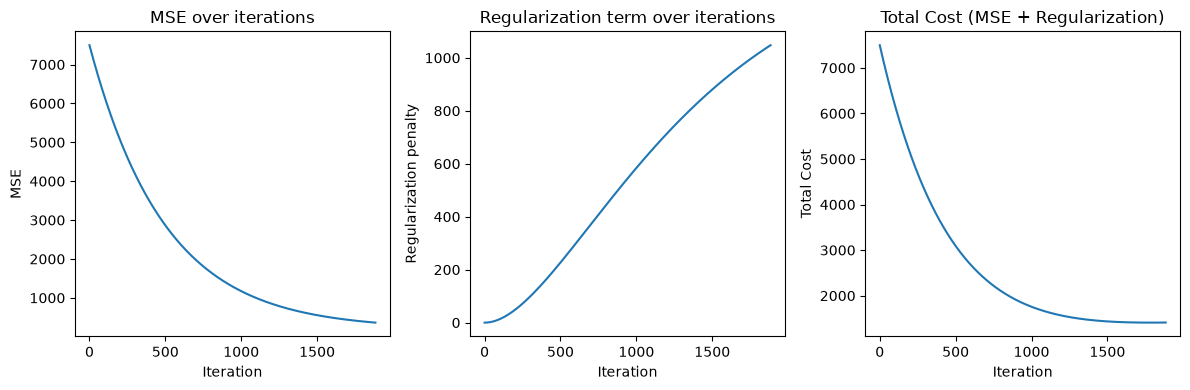

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history_l2['mse_history'])
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('MSE over iterations')

plt.subplot(1, 3, 2)
plt.plot(history_l2['regularization_history'])
plt.xlabel('Iteration')
plt.ylabel('Regularization penalty')
plt.title('Regularization term over iterations')

plt.subplot(1, 3, 3)
plt.plot(history_l2['cost_history'])
plt.xlabel('Iteration')
plt.ylabel('Total Cost')
plt.title('Total Cost (MSE + Regularization)')

plt.tight_layout()
plt.show()